In [34]:
import matplotlib.pyplot as plt
%matplotlib inline

In [35]:
#importing tensorflow libraries required
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D,Dropout

In [3]:
#loading path
train_path='Manufacture_dataset/casting_data/casting_data/train'
test_path='Manufacture_dataset/casting_data/casting_data/test'

In [9]:
#Creating the objects of the ImageDataGenerator class
Dtgen_train=ImageDataGenerator(preprocessing_function=preprocess_input,validation_split=0.2)

Dtgen_test=ImageDataGenerator(preprocessing_function=preprocess_input)

In [11]:
#Creating generators for the train, validation and test

trn_gen = Dtgen_train.flow_from_directory(train_path,
                                          target_size=(224,224),
                                          batch_size=32,
                                          class_mode='binary',
                                          subset='training')

vld_gen = Dtgen_train.flow_from_directory(train_path,
                                                target_size=(224,224),
                                                batch_size=32,
                                                class_mode='binary',
                                                subset='validation'
                                                )

tst_gen = Dtgen_test.flow_from_directory(test_path,
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='binary',
                                               shuffle=False)

Found 5307 images belonging to 2 classes.
Found 1326 images belonging to 2 classes.
Found 715 images belonging to 2 classes.


There is no seperate folder for the training and validation in the dataset provided. Hence using tensorflow we split 80% of data in train folder as training and rest as validation.

In [12]:
print(trn_gen.class_indices)

{'def_front': 0, 'ok_front': 1}


In [13]:
MobNet_base= MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
MobNet_base.trainable=False

In [16]:
print(MobNet_base)

<Functional name=mobilenetv2_1.00_224, built=True>


In [20]:
# Classifier customization
pool = GlobalAveragePooling2D()(MobNet_base.output)
layer= Dense(128, activation='relu')(pool)
drop= Dropout(0.5)(layer)
lst_layer= Dense(1, activation='sigmoid')(drop)

In [21]:
model= Model(inputs=MobNet_base.input, outputs=lst_layer)

In [26]:
#Compiling the model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [29]:
history = model.fit(
    trn_gen,
    validation_data=vld_gen,
    epochs=5
)

Epoch 1/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 81s 446ms/step - accuracy: 0.8751 - loss: 0.2962 - val_accuracy: 0.9706 - val_loss: 0.1102
Epoch 2/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 72s 436ms/step - accuracy: 0.9736 - loss: 0.0929 - val_accuracy: 0.9842 - val_loss: 0.0613
Epoch 3/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 75s 452ms/step - accuracy: 0.9840 - loss: 0.0579 - val_accuracy: 0.9887 - val_loss: 0.0490
Epoch 4/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 76s 456ms/step - accuracy: 0.9866 - loss: 0.0499 - val_accuracy: 0.9917 - val_loss: 0.0332
Epoch 5/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 78s 470ms/step - accuracy: 0.9891 - loss: 0.0356 - val_accuracy: 0.9917 - val_loss: 0.0380


In [32]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [33]:
print(history.history['accuracy'])

[0.8750706911087036, 0.9736197590827942, 0.9839833974838257, 0.9866214394569397, 0.9890710115432739]


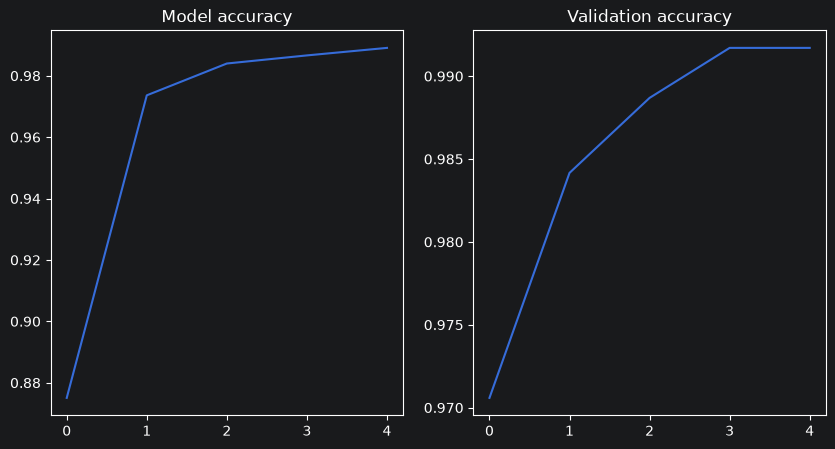

In [46]:
fig,axis= plt.subplots(1,2,figsize=(10,5))
axis[0].plot( history.history['accuracy'])
axis[0].title.set_text('Model accuracy')
axis[1].plot(history.history['val_accuracy'])
axis[1].title.set_text('Validation accuracy')

In [48]:
test_result = model.evaluate(tst_gen)

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 339ms/step - accuracy: 0.9916 - loss: 0.0349 


In [49]:
pred = model.predict(tst_gen)

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 340ms/step 


In [56]:
pred_class=(pred > 0.5).astype(int)
true_class=tst_gen.classes

Accuracy: 99.16%
[[447   6]
 [  0 262]]


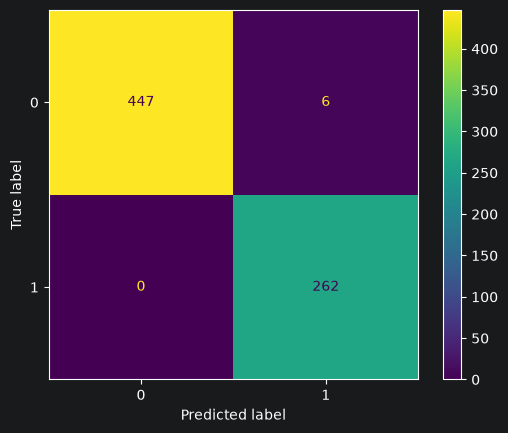

In [60]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
acc_percent=accuracy_score(true_class,pred_class)*100
con_mat=confusion_matrix(true_class,pred_class)
disp=ConfusionMatrixDisplay(confusion_matrix=con_mat)
print(f'Accuracy: {acc_percent:.2f}%')
print(con_mat)
disp.plot()

In [61]:
#saving the model
model.save('Defect_detection.keras')